In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import pandas as pd
import arrow

In [2]:
meshmask = xr.open_dataset('/ocean/atall/MOAD/grid/mesh_mask_202310b.nc')
tmask = meshmask.tmask
mbathy = meshmask.mbathy
lon = meshmask.nav_lon
lat = meshmask.nav_lat

In [3]:
def collapse_time_counter(da):
    """Remove/aggregate the NEMO time_counter dim."""
    if 'time_counter' in da.dims:
        if da.sizes['time_counter'] > 1:
            da = da.mean('time_counter')  # daily mean if multiple records/day
        else:
            da = da.isel(time_counter=0, drop=True)
    return da

def top10_sum(da, depth_mask):
    """Sum over top 10 m (use your <10 mask), returns 2D (y,x) after depth sum."""
    out = da.isel(deptht=depth_mask).sum('deptht', skipna=True)
    return out

In [ ]:
# Time settings
epsilon = 1e-15
epsilon2 = 1e-40  # for domain integration percentage change
syear, smonth, sday = (2018, 1, 1)
eyear, emonth, eday = (2018, 1, 7)
startdate = arrow.get(syear, smonth, sday)
enddate = arrow.get(eyear, emonth, eday)
dir24 = '/ocean/atall/MOAD/Model/202410b/oxygen_forZ2018/'
dirWW = '/ocean/atall/MOAD/Model/202410b/wastewatero2_zeroNut/'

In [7]:
# Time settings
epsilon = 1e-15
epsilon2 = 1e-40  # for domain integration percentage change
syear, smonth, sday = (2018, 1, 1)
eyear, emonth, eday = (2018, 1, 7)
startdate = arrow.get(syear, smonth, sday)
enddate = arrow.get(eyear, emonth, eday)
dir24 = '/ocean/atall/MOAD/Model/202410b/oxygen_forZ2018/'
dirWW = '/ocean/atall/MOAD/Model/202410b/wastewatero2_zeroNut/'

# Containers for maps
do_abs_list, nitrate_abs_list, ammonium_abs_list, diatoms_abs_list = [], [], [], []
do_pct_list, nitrate_pct_list, ammonium_pct_list, diatoms_pct_list = [], [], [], []

# Containers for domain-integrated values
do_abs_domain, nitrate_abs_domain, ammonium_abs_domain, diatoms_abs_domain = [], [], [], []
do_pct_domain, nitrate_pct_domain, ammonium_pct_domain, diatoms_pct_domain = [], [], [], []

# Volume for integration
vol = meshmask.e1t[0, :, :] * meshmask.e2t[0, :, :] * meshmask.e3t_0[0, :, :, :]  

# Loop over days
for day in arrow.Arrow.range('day', startdate, enddate):
    year = day.year
    yr2 = day.strftime("%y")
    month = day.month
    Month = day.strftime("%b").lower()
    dayn = day.day

    fn_chem24 = f'{dir24}{dayn:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{dayn:02}_{year}{month:02}{dayn:02}_chem_T.nc'
    fn_chemWW = f'{dirWW}{dayn:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{dayn:02}_{year}{month:02}{dayn:02}_chem_T.nc'
    fn_biol24 = f'{dir24}{dayn:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{dayn:02}_{year}{month:02}{dayn:02}_biol_T.nc'
    fn_biolWW = f'{dirWW}{dayn:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{dayn:02}_{year}{month:02}{dayn:02}_biol_T.nc'

    ds_chem24 = xr.open_dataset(fn_chem24)
    ds_chemWW = xr.open_dataset(fn_chemWW)
    ds_biol24 = xr.open_dataset(fn_biol24)
    ds_biolWW = xr.open_dataset(fn_biolWW)

    mask_10m_chem = ds_chem24.deptht < 10
    mask_10m_biol = ds_biol24.deptht < 10

    # Absolute difference
    do_diff = ds_chemWW.dissolved_oxygen - ds_chem24.dissolved_oxygen
    nitrate_diff = ds_biolWW.nitrate - ds_biol24.nitrate
    ammonium_diff = ds_biolWW.ammonium - ds_biol24.ammonium
    diatoms_diff = ds_biolWW.diatoms - ds_biol24.diatoms

    # Percentage change : avoid /0
    do_pct = (do_diff / (ds_chem24.dissolved_oxygen + epsilon)) * 100
    nitrate_pct = (nitrate_diff / (ds_biol24.nitrate + epsilon)) * 100
    ammonium_pct = (ammonium_diff / (ds_biol24.ammonium + epsilon)) * 100
    diatoms_pct = (diatoms_diff / (ds_biol24.diatoms + epsilon)) * 100

    # Integrate 0–10 m, then remove time_counter so each is (y,x)
    do_abs_2d       = collapse_time_counter(top10_sum(do_diff,       mask_10m_chem))
    nitrate_abs_2d  = collapse_time_counter(top10_sum(nitrate_diff,  mask_10m_biol))
    ammonium_abs_2d = collapse_time_counter(top10_sum(ammonium_diff, mask_10m_biol))
    diatoms_abs_2d  = collapse_time_counter(top10_sum(diatoms_diff,  mask_10m_biol))

    do_pct_2d       = collapse_time_counter(top10_sum(do_pct,       mask_10m_chem))
    nitrate_pct_2d  = collapse_time_counter(top10_sum(nitrate_pct,  mask_10m_biol))
    ammonium_pct_2d = collapse_time_counter(top10_sum(ammonium_pct, mask_10m_biol))
    diatoms_pct_2d  = collapse_time_counter(top10_sum(diatoms_pct,  mask_10m_biol))

    # Append clean 2D slices
    do_abs_list.append(do_abs_2d)
    nitrate_abs_list.append(nitrate_abs_2d)
    ammonium_abs_list.append(ammonium_abs_2d)
    diatoms_abs_list.append(diatoms_abs_2d)

    do_pct_list.append(do_pct_2d)
    nitrate_pct_list.append(nitrate_pct_2d)
    ammonium_pct_list.append(ammonium_pct_2d)
    diatoms_pct_list.append(diatoms_pct_2d)

    # Domain integrated (volume-weighted)
    do_abs_domain.append((do_diff * vol).sum().values)
    nitrate_abs_domain.append((nitrate_diff * vol).sum().values)
    ammonium_abs_domain.append((ammonium_diff * vol).sum().values)
    diatoms_abs_domain.append((diatoms_diff * vol).sum().values)

    do_pct_domain.append(((do_diff * vol).sum() / ((ds_chem24.dissolved_oxygen * vol).sum() + epsilon2)).values * 100)
    nitrate_pct_domain.append(((nitrate_diff * vol).sum() / ((ds_biol24.nitrate * vol).sum() + epsilon2)).values * 100)
    ammonium_pct_domain.append(((ammonium_diff * vol).sum() / ((ds_biol24.ammonium * vol).sum() + epsilon2)).values * 100)
    diatoms_pct_domain.append(((diatoms_diff * vol).sum() / ((ds_biol24.diatoms * vol).sum() + epsilon2)).values * 100)


In [8]:
time_index = pd.date_range(start=f"{syear}-{smonth:02}-{sday:02}",
                           end=f"{eyear}-{emonth:02}-{eday:02}", freq="D")

# Absolute
do_abs_da       = xr.concat(do_abs_list,       dim='time').assign_coords(time=time_index[:len(do_abs_list)])
nitrate_abs_da  = xr.concat(nitrate_abs_list,  dim='time').assign_coords(time=time_index[:len(nitrate_abs_list)])
ammonium_abs_da = xr.concat(ammonium_abs_list, dim='time').assign_coords(time=time_index[:len(ammonium_abs_list)])
diatoms_abs_da  = xr.concat(diatoms_abs_list,  dim='time').assign_coords(time=time_index[:len(diatoms_abs_list)])

# Percent
do_pct_da       = xr.concat(do_pct_list,       dim='time').assign_coords(time=time_index[:len(do_pct_list)])
nitrate_pct_da  = xr.concat(nitrate_pct_list,  dim='time').assign_coords(time=time_index[:len(nitrate_pct_list)])
ammonium_pct_da = xr.concat(ammonium_pct_list, dim='time').assign_coords(time=time_index[:len(ammonium_pct_list)])
diatoms_pct_da  = xr.concat(diatoms_pct_list,  dim='time').assign_coords(time=time_index[:len(diatoms_pct_list)])

In [9]:
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad('white')
def _frame2d(da, frame):
    # Expect (time,y,x); if anything else sneaks in, drop it safely
    sel = da.isel(time=frame)
    return sel.squeeze().values  # pass a plain 2D ndarray to contourf

def make_animation(data_list, title_prefix, levels, filename):
    fig, axs = plt.subplots(1, 4, figsize=(20, 6), constrained_layout=True)

    # first frame
    csets = []
    for i in range(4):
        axs[i].contour(lon, lat, mbathy[0,:,:], levels=[0], colors='dimgray', linewidths=0.5)
        Z = _frame2d(data_list[i], 0)
        if hasattr(Z, 'mask'):
            Z = np.where(Z.mask, np.nan, Z)
        cs = axs[i].contourf(lon, lat, Z, levels=levels[i], cmap=cmap, extend='both')
        axs[i].set_title(f"{title_prefix[i]} on {str(data_list[i].time.values[0])[:10]} (0–10 m sum)")
        axs[i].set_ylim(47, 51); axs[i].set_xlim(-126, -122)
        fig.colorbar(cs, ax=axs[i])
        csets.append(cs)

    def update(frame):
        artists = []
        for i in range(4):
            axs[i].contour(lon, lat, mbathy[0,:,:], levels=[0], colors='dimgray', linewidths=0.5)
            for coll in csets[i].collections:
                coll.remove()
            Z = _frame2d(data_list[i], frame)
            Z = np.ma.masked_invalid(Z)
            csets[i] = axs[i].contourf(lon, lat, Z, levels=levels[i], cmap=cmap, extend='both')
            axs[i].set_title(f"{title_prefix[i]} on {str(data_list[i].time.values[frame])[:10]} (0–10 m sum)")
            artists += csets[i].collections
        return artists

    ani = FuncAnimation(fig, update, frames=data_list[0].sizes['time'], blit=False)
    ani.save(filename, writer='ffmpeg', fps=2)
    #plt.close(fig)


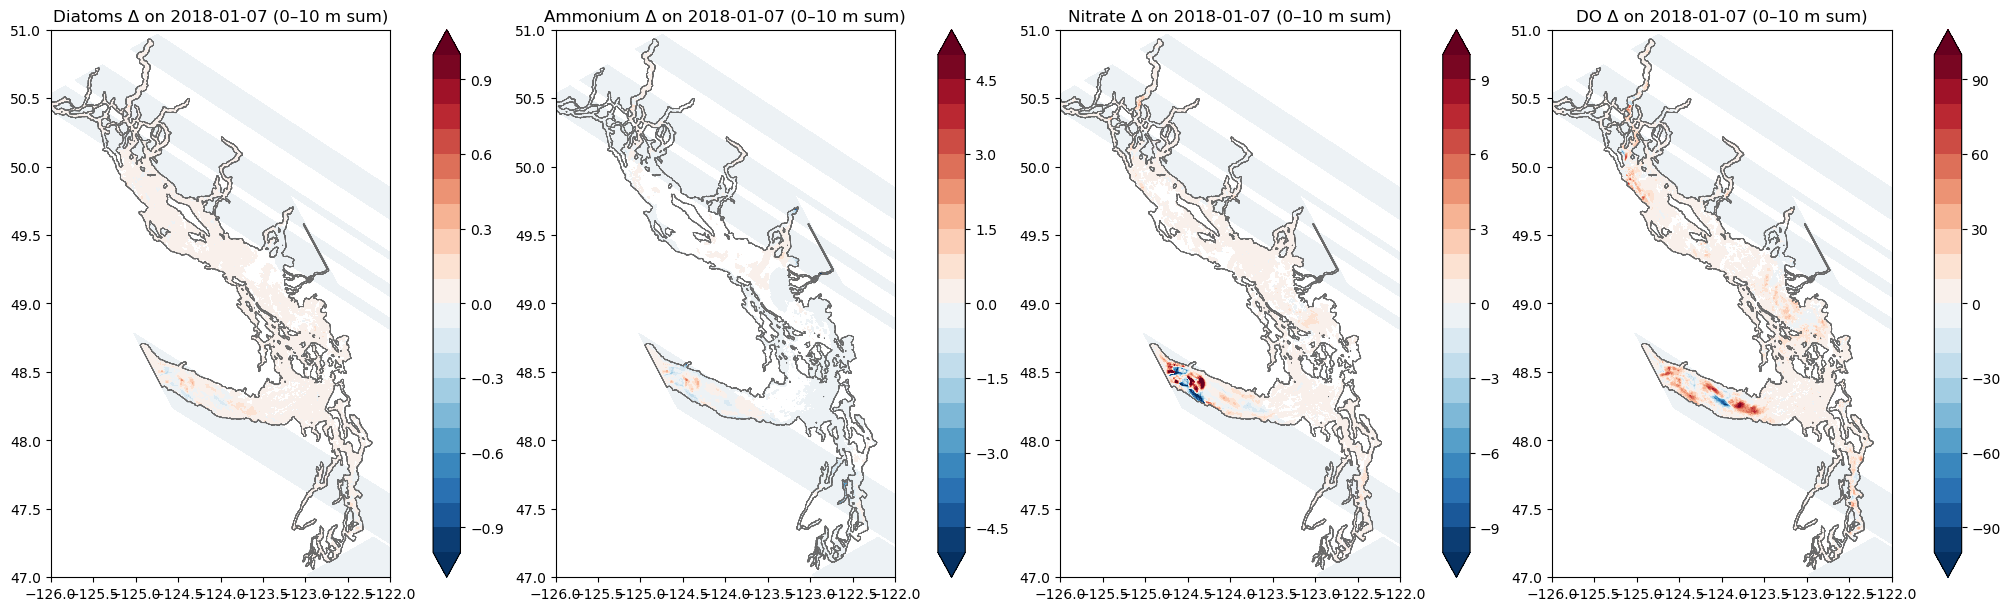

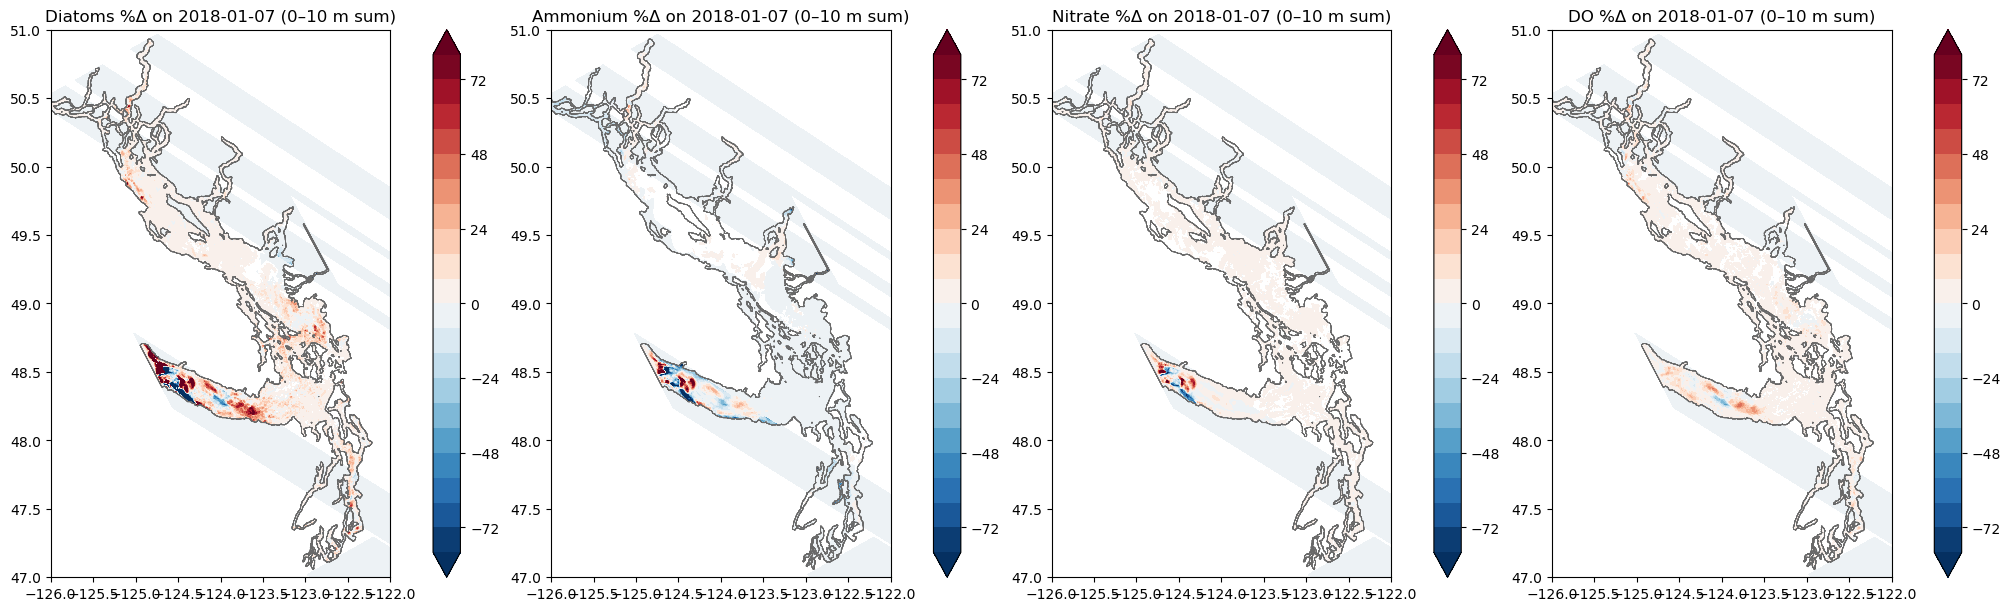

In [10]:
# Absolute difference animation
make_animation([diatoms_abs_da, ammonium_abs_da, nitrate_abs_da, do_abs_da],
               ['Diatoms Δ', 'Ammonium Δ', 'Nitrate Δ', 'DO Δ'],
               [np.linspace(-1, 1, 21), np.linspace(-5, 5, 21), np.linspace(-10, 10, 21), np.linspace(-100, 100, 21)],
               'figs/absolute_diff_1stWeekJan2018_Zero_Nut.mp4')

# Percentage change animation
make_animation([diatoms_pct_da, ammonium_pct_da, nitrate_pct_da, do_pct_da],
               ['Diatoms %Δ', 'Ammonium %Δ', 'Nitrate %Δ', 'DO %Δ'],
               [np.linspace(-80, 80, 21), np.linspace(-80, 80, 21), np.linspace(-80, 80, 21), np.linspace(-80, 80, 21)],
               'figs/percentage_change_1stWeekJan2018_zeroNut.mp4')

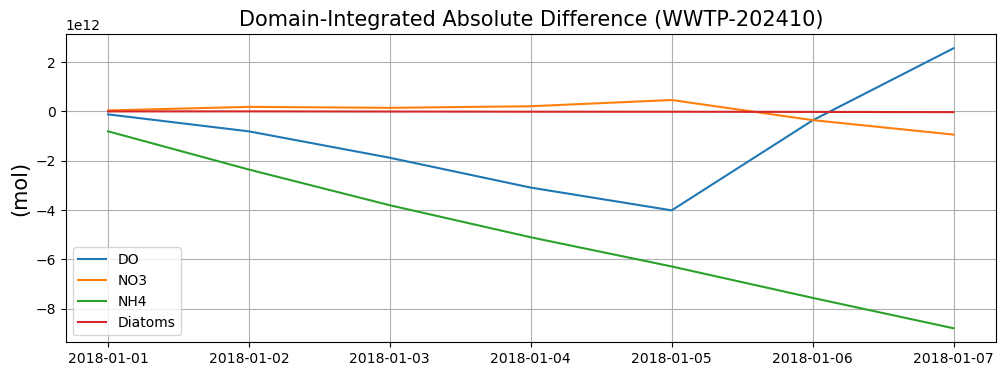

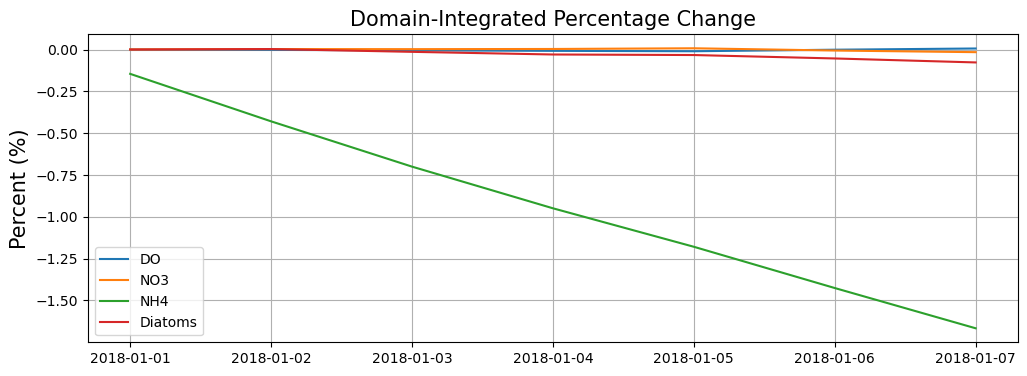

In [11]:
# Time series plot
plt.figure(figsize=(12,4))
plt.plot(time_index, do_abs_domain, label='DO')
plt.plot(time_index, nitrate_abs_domain, label='NO3')
plt.plot(time_index, ammonium_abs_domain, label='NH4')
plt.plot(time_index, diatoms_abs_domain, label='Diatoms')
plt.legend()
plt.title('Domain-Integrated Absolute Difference (WWTP-202410)', fontsize=15)
plt.ylabel('(mol)', fontsize=15)
plt.savefig('figs/domain_integrated_abs_1stWeekJan2018_zeroNut.png')
plt.grid()

plt.figure(figsize=(12,4))
plt.plot(time_index, do_pct_domain, label='DO')
plt.plot(time_index, nitrate_pct_domain, label='NO3')
plt.plot(time_index, ammonium_pct_domain, label='NH4')
plt.plot(time_index, diatoms_pct_domain, label='Diatoms')
plt.legend()
plt.title('Domain-Integrated Percentage Change', fontsize=15)
plt.ylabel('Percent (%)', fontsize=15)
plt.savefig('figs/domain_integrated_pct_1stWeekJan2018_zeroNut.png')
plt.grid()
#plt.close()